# Notebook 01 — Data Cleaning & Integration
## Cardiovascular Care Deserts in Pará, Brazil (2019–2023)

**O que este notebook faz:**  
Pega cinco arquivos brutos de fontes diferentes (DATASUS e IBGE), limpa cada um, e combina tudo em um único DataFrame pronto para análise de clustering.

**Por que limpeza é a etapa mais importante:**  
DATASUS e IBGE exportam dados pensando em relatórios para humanos, não em análise de máquina. Isso significa cabeçalhos com múltiplas linhas, rodapés de nota explicativa, valores ausentes representados como `"-"` ou `"..."`, e codificações de texto inconsistentes. Se você pular esta etapa e tentar rodar clustering diretamente, o modelo vai travar ou produzir lixo.

---

## Seção 0 — Imports

**O que são imports:**  
Python por si só não sabe fazer estatística, ler Excel ou desenhar mapas. `import` é o comando que carrega bibliotecas externas — pacotes de código que outras pessoas escreveram e que você usa como ferramentas. Você instala uma vez, importa toda vez que abre o notebook.

| Biblioteca | Para que serve neste projeto |
|---|---|
| `pandas` | Ler e manipular tabelas (CSVs) |
| `numpy` | Cálculos matemáticos rápidos |
| `matplotlib` | Gráficos |
| `geopandas` | Ler shapefiles e desenhar mapas |
| `os`, `warnings` | Utilitários do sistema |

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import os
import warnings
warnings.filterwarnings('ignore')

print('✅ Bibliotecas carregadas com sucesso')

✅ Bibliotecas carregadas com sucesso


---
## Seção 1 — Caminhos dos Arquivos

**Por que centralizar os caminhos:**  
Se você mudar de pasta ou computador, você altera só esta célula — o resto do notebook continua funcionando. Isso se chama **separação de configuração e lógica**, e é uma prática básica de código limpo.

**`raw/`** é a pasta onde ficam os arquivos originais — nunca editados, nunca sobrescritos.  
**`processed/`** é onde salvamos os arquivos depois de limpos.  
Essa separação garante que você pode sempre voltar ao dado original se algo der errado.

In [9]:
PATH_MORTALITY   = '../data/raw/mortalitybycity.csv'
PATH_PROCEDURES  = '../data/raw/proceduresbycity.csv'
PATH_PIB         = '../data/raw/pib.csv'
PATH_POPULATION  = '../data/raw/population.csv'
PATH_SHAPEFILE   = '../data/raw/PA_Municipios_2022.shp'

os.makedirs('../data/processed', exist_ok=True)

print('✅ Paths defined and processed data folder created')

✅ Paths defined and processed data folder created


---
## Seção 2 — Carregando e Limpando Mortalidade

**O que este arquivo contém:**  
Óbitos por causas cardiovasculares (CID-10: I20 a I25 — angina, infarto agudo, infarto recorrente, doença isquêmica) por município do Pará, de 2019 a 2023.

**Por que `skiprows=4`:**  
O DATASUS coloca 4 linhas de cabeçalho antes dos dados reais — título do relatório, tipo de variável, categoria CID, período. Essas linhas não são dados. `skiprows=4` diz ao pandas: pule as 4 primeiras linhas e comece a ler a partir da linha 5.

**Por que `encoding='latin-1'`:**  
Arquivos brasileiros frequentemente usam o padrão de codificação latin-1 (também chamado ISO-8859-1) em vez de UTF-8. Sem especificar isso, Python não sabe interpretar caracteres como `ã`, `ç`, `é` e trava com erro.

**Por que `sep=';'`:**  
CSV significa *Comma-Separated Values* — mas o DATASUS usa ponto-e-vírgula como separador, não vírgula. O `sep=';'` especifica isso.

In [10]:
# --- 1st STEP: Load Raw Data ---
mort_raw = pd.read_csv(
    PATH_MORTALITY,
    encoding='latin-1',   # codificação de caracteres brasileiros
    sep=';',              # separador é ponto-e-vírgula
    skiprows=4,           # pular 4 linhas de cabeçalho do DATASUS
    on_bad_lines='skip'   # linhas mal formatadas (rodapés) são ignoradas
)

# --- 2nd STEP: Rename Columns ---
# Defining clearer names.
mort_raw.columns = ['municipio', 'mort_2019', 'mort_2020', 'mort_2021', 'mort_2022', 'mort_2023', 'mort_total']

print('Primeiras linhas do arquivo bruto:')
mort_raw.head(8)

Primeiras linhas do arquivo bruto:


,municipio,mort_2019,mort_2020,mort_2021,mort_2022,mort_2023,mort_total
0,MUNICIPIO IGNORADO - PA,2,2.0,1.0,3.0,3.0,11.0
1,150010 ABAETETUBA,33,30.0,39.0,60.0,45.0,207.0
2,150013 ABEL FIGUEIREDO,2,2.0,5.0,3.0,2.0,14.0
3,150020 ACARA,16,21.0,21.0,24.0,27.0,109.0
4,150030 AFUA,7,6.0,3.0,2.0,6.0,24.0
5,150034 AGUA AZUL DO NORTE,2,3.0,6.0,4.0,12.0,27.0
6,150040 ALENQUER,27,28.0,37.0,37.0,22.0,151.0
7,150050 ALMEIRIM,9,25.0,11.0,11.0,18.0,74.0


In [11]:
# --- PASSO 3: Remover linhas que não são municípios ---
# O arquivo tem linhas de rodapé como "Fonte: Ministério da Saúde", "Total", "Notas:"
# A coluna 'municipio' dessas linhas começa com espaço, contém 'Fonte', 'Total', etc.
# Precisamos remover essas linhas para não confundir o modelo de clustering.

# Mantém apenas linhas onde o município tem um código IBGE de 6 dígitos no início
# O código IBGE é sempre 6 números seguidos de um espaço e o nome do município
# Example: '150010 ABAETETUBA'
mort = mort_raw[mort_raw['municipio'].str.match(r'^\"?\d{6}', na=False)].copy()

# --- PASSO 4: Extrair código IBGE e nome do município ---
# A coluna 'municipio' tem o código e o nome juntos: '150010 ABAETETUBA'
# Vamos separar os dois para poder fazer joins com outros datasets
mort['cod_ibge'] = mort['municipio'].str.extract(r'(\d{6})')  # extrai 6 dígitos
mort['nome_municipio'] = mort['municipio'].str.replace(r'^\d+\s+', '', regex=True).str.strip()
mort['nome_municipio'] = mort['nome_municipio'].str.replace('"', '').str.strip()
mort['cod_ibge'] = mort['cod_ibge'].str.strip()

# --- PASSO 5: Garantir que colunas numéricas são números ---
# pandas pode ter lido os valores como texto (string) se havia valores como '-' ou '...'
# errors='coerce' converte o que não puder virar número em NaN (ausente)
year_cols = ['mort_2019', 'mort_2020', 'mort_2021', 'mort_2022', 'mort_2023', 'mort_total']
for col in year_cols:
    mort[col] = pd.to_numeric(mort[col], errors='coerce').fillna(0)

# --- PASSO 6: Selecionar apenas as colunas que importam ---
mort = mort[['cod_ibge', 'nome_municipio'] + year_cols]

print(f'✅ Mortalidade: {len(mort)} municípios carregados')
print(f'Municípios com óbito zero em todos os anos: {(mort["mort_total"] == 0).sum()}')
mort.head()

✅ Mortalidade: 144 municípios carregados
Municípios com óbito zero em todos os anos: 0


,cod_ibge,nome_municipio,mort_2019,mort_2020,mort_2021,mort_2022,mort_2023,mort_total
1,150010,ABAETETUBA,33.0,30.0,39.0,60.0,45.0,207.0
2,150013,ABEL FIGUEIREDO,2.0,2.0,5.0,3.0,2.0,14.0
3,150020,ACARA,16.0,21.0,21.0,24.0,27.0,109.0
4,150030,AFUA,7.0,6.0,3.0,2.0,6.0,24.0
5,150034,AGUA AZUL DO NORTE,2.0,3.0,6.0,4.0,12.0,27.0


---
## Seção 3 — Carregando e Limpando Procedimentos

**O que este arquivo contém:**  
Cateterismos cardíacos realizados via SUS por município, 2019–2023. Cada linha tem o município, quantidade de AIH (Autorização de Internação Hospitalar) aprovadas e o valor total pago.

**Observação crítica:** Nos dados que você baixou, **apenas 2 municípios aparecem**: Belém e Ananindeua. Isso não é erro de download — é o dado real. Significa que os outros 142 municípios do Pará tiveram **zero procedimentos de cateterismo cardíaco** no período. Esse é o achado central do projeto.

**O que vamos fazer:** Criar um DataFrame com todos os municípios e preencher com zero os que não aparecem no arquivo de procedimentos.

In [12]:
proc_raw = pd.read_csv(
    PATH_PROCEDURES,
    encoding='latin-1',
    sep=';',
    skiprows=4,
    on_bad_lines='skip'
)
proc_raw.columns = ['municipio', 'aih_aprovadas', 'valor_total']

# Manter apenas linhas com código IBGE válido (remove Total, Fonte, etc.)
proc = proc_raw[proc_raw['municipio'].str.match(r'^\"?\d{6}', na=False)].copy()

proc['cod_ibge'] = proc['municipio'].str.extract(r'(\d{6})')

# Valor total usa vírgula como decimal no Brasil — converter para float
proc['aih_aprovadas'] = pd.to_numeric(proc['aih_aprovadas'], errors='coerce').fillna(0)
proc['valor_total_reais'] = proc['valor_total'].astype(str).str.replace(',', '.').pipe(
    pd.to_numeric, errors='coerce').fillna(0)

proc = proc[['cod_ibge', 'aih_aprovadas', 'valor_total_reais']]

print(f'✅ Procedimentos: {len(proc)} municípios com dados')
print('(Municípios sem procedimentos receberão zero no merge)')
proc

✅ Procedimentos: 2 municípios com dados
(Municípios sem procedimentos receberão zero no merge)


,cod_ibge,aih_aprovadas,valor_total_reais
0,150080,64.0,313573.94
1,150140,5260.0,29413499.28


---
## Seção 4 — Carregando População por Município

**Por que precisamos de população:**  
Comparar óbitos absolutos entre municípios é injusto — Belém tem 1.5 milhão de habitantes, Melgaço tem 25 mil. O jeito correto é calcular a **taxa por 100.000 habitantes**, que normaliza os valores e torna municípios de tamanhos diferentes comparáveis entre si.

**Fórmula:** `taxa = (óbitos / população) × 100.000`

**Formato esperado do IBGE:** O arquivo tem código do município, nome, e estimativas populacionais por ano.

In [17]:
# File structure confirmed: semicolon-separated, quoted fields, header at row 3

pop = pd.read_csv(
    PATH_POPULATION,
    encoding='utf-8-sig',
    sep=';',
    skiprows=3,          # skip rows 0–2 (IBGE title, notes, blank)
    on_bad_lines='skip',
    quotechar='"'
)

# Keep only rows that are actual municipalities — they contain "(PA)"
pop = pop[pop.iloc[:, 0].str.contains(r'\(PA\)', na=False)].copy()

# Rename columns — confirmed order: name, 2019, 2020, 2021, 2024
# NOTE: 2022 and 2023 are not available in this export.
# We use 2021 as the population baseline (midpoint of the 2019–2023 study period).
# This is standard practice in epidemiological studies when exact-year data is unavailable.
pop.columns = ['municipio_raw', 'pop_2019', 'pop_2020', 'pop_2021', 'pop_2024']

# Clean numeric columns
for col in ['pop_2019', 'pop_2020', 'pop_2021', 'pop_2024']:
    pop[col] = pd.to_numeric(
        pop[col].astype(str).str.replace('"', '').str.replace('.', '').str.strip(),
        errors='coerce'
    )

# Clean municipality name — remove "(PA)" and quotes for matching
pop['nome_clean'] = (pop['municipio_raw']
                     .str.replace('"', '')
                     .str.replace(r'\s*\(PA\)', '', regex=True)
                     .str.strip()
                     .str.upper())

# We'll use 2021 as baseline population
pop['populacao'] = pop['pop_2021']

print(f"✅ Population: {len(pop)} municipalities loaded")
print(f"   Baseline year: 2021 (midpoint of study period)")
print(f"   Missing values: {pop['populacao'].isna().sum()}")
print(pop[['municipio_raw', 'populacao']].head())

✅ Population: 144 municipalities loaded
   Baseline year: 2021 (midpoint of study period)
   Missing values: 0
             municipio_raw  populacao
0          Abaetetuba (PA)     160439
1     Abel Figueiredo (PA)       7536
2               Acará (PA)      55744
3                Afuá (PA)      39910
4  Água Azul do Norte (PA)      27797


---
## Seção 5 — Carregando PIB por Município

**Por que PIB per capita:**  
O PIB per capita é uma proxy de renda média e desenvolvimento econômico do município. A hipótese do projeto é que municípios mais pobres têm menos acesso a procedimentos cardíacos — o clustering vai testar isso empiricamente.

**O que você baixou:** PIB bruto total. Vamos calcular PIB per capita dividindo pelo tamanho da população. Isso é melhor do que usar o valor publicado diretamente, porque garante consistência entre as fontes.

In [18]:
with open(PATH_PIB, encoding='utf-8-sig') as f:
    lines = f.readlines()

pa_lines = [(i, line.strip()) for i, line in enumerate(lines) if '(PA)' in line]
print(f"Lines with (PA): {len(pa_lines)}")
if pa_lines:
    first_idx = pa_lines[0][0]
    print(f"\nHeader row [{first_idx-1}]: {repr(lines[first_idx-1].strip())}")
    print(f"First 3 data rows:")
    for i, line in pa_lines[:3]:
        print(f"  [{i}] {repr(line)}")

Lines with (PA): 144

Header row [3]: '"Município";"2019";"2020";"2021";"2022";"2023"'
First 3 data rows:
  [4] '"Abaetetuba (PA)";"1491621";"1659693";"1947974";"2193300";"2441092"'
  [5] '"Abel Figueiredo (PA)";"84902";"95863";"105404";"126585";"131077"'
  [6] '"Acará (PA)";"755091";"881812";"1432521";"1242612";"2111467"'


In [19]:
# Structure confirmed: same format as population file
# Values are in thousand reais (mil R$) — IBGE standard for municipal GDP

pib = pd.read_csv(
    PATH_PIB,
    encoding='utf-8-sig',
    sep=';',
    skiprows=3,
    on_bad_lines='skip',
    quotechar='"'
)

# Keep only Pará municipalities
pib = pib[pib.iloc[:, 0].str.contains(r'\(PA\)', na=False)].copy()

# Rename — confirmed columns: name, 2019, 2020, 2021, 2022, 2023
pib.columns = ['municipio_raw', 'pib_2019', 'pib_2020', 'pib_2021', 'pib_2022', 'pib_2023']

# Clean numeric columns (remove quotes, dots used as thousand separators)
for col in ['pib_2019', 'pib_2020', 'pib_2021', 'pib_2022', 'pib_2023']:
    pib[col] = pd.to_numeric(
        pib[col].astype(str).str.replace('"', '').str.replace('.', '').str.strip(),
        errors='coerce'
    )

# Average GDP across all 5 years for a stable baseline
# Why average instead of a single year: GDP fluctuates year to year due to
# commodity prices (very relevant in Pará — iron ore, soy, timber).
# A 5-year average captures the structural economic level, not a spike or dip.
pib['pib_medio_mil_reais'] = pib[['pib_2019','pib_2020','pib_2021','pib_2022','pib_2023']].mean(axis=1)

# Clean name for matching
pib['nome_clean'] = (pib['municipio_raw']
                     .str.replace('"', '')
                     .str.replace(r'\s*\(PA\)', '', regex=True)
                     .str.strip()
                     .str.upper())

print(f"✅ GDP: {len(pib)} municipalities loaded")
print(f"   Missing values: {pib['pib_medio_mil_reais'].isna().sum()}")
print(pib[['municipio_raw', 'pib_medio_mil_reais']].head())

✅ GDP: 144 municipalities loaded
   Missing values: 0
             municipio_raw  pib_medio_mil_reais
0          Abaetetuba (PA)           16782442.2
1     Abel Figueiredo (PA)             934838.4
2               Acará (PA)           11487842.2
3                Afuá (PA)            4248176.6
4  Água Azul do Norte (PA)            6227411.8


---
## Seção 6 — Merge: Unindo Tudo em Um Único DataFrame

**O que é um merge (join):**  
É a operação de combinar duas tabelas que compartilham uma coluna em comum — neste caso, o `cod_ibge`. É equivalente ao VLOOKUP do Excel, mas muito mais poderoso.

**Tipos de merge:**
- `left`: mantém todos os municípios da tabela da esquerda, mesmo que não tenham correspondência na da direita (municípios sem procedimentos ficam com zero)
- `inner`: mantém só os que aparecem nas duas tabelas (descartaria municípios sem PIB, por exemplo)

Usamos `left` com a mortalidade como base — todos os 144 municípios com óbito ficam, e os sem procedimento recebem `NaN` que depois vira `0`.

In [21]:
import unicodedata

# Why this function exists:
# The mortality file has names like "ABAETETUBA" (uppercase, no accents).
# Population and PIB files have "Abaetetuba (PA)" (mixed case, with accents).
# We can't match them directly — we need to normalize both sides to the same format
# before comparing, then use cod_ibge from the mortality file as the master key.

def normalize(s):
    """Remove accents, uppercase, strip extra spaces."""
    s = str(s).upper().strip()
    # NFD decomposition separates base letters from accent marks
    # We then drop anything in the 'Mn' (Mark, Nonspacing) category = accent marks
    s = ''.join(c for c in unicodedata.normalize('NFD', s)
                if unicodedata.category(c) != 'Mn')
    return ' '.join(s.split())

# Build a lookup table: normalized name → cod_ibge, from the mortality file
# (mortality has both name and IBGE code, which the other files lack)
name_to_code = {
    normalize(row['nome_municipio']): row['cod_ibge']
    for _, row in mort.iterrows()
}

# Apply normalization to population and PIB files
pop['cod_ibge'] = pop['nome_clean'].apply(
    lambda x: name_to_code.get(normalize(x), None)
)
pib['cod_ibge'] = pib['nome_clean'].apply(
    lambda x: name_to_code.get(normalize(x), None)
)

# Report any names that didn't match
pop_unmatched = pop[pop['cod_ibge'].isna()]['municipio_raw'].tolist()
pib_unmatched = pib[pib['cod_ibge'].isna()]['municipio_raw'].tolist()

if pop_unmatched:
    print(f"⚠️  Population — {len(pop_unmatched)} unmatched: {pop_unmatched}")
else:
    print("✅ Population — all municipalities matched")

if pib_unmatched:
    print(f"⚠️  GDP — {len(pib_unmatched)} unmatched: {pib_unmatched}")
else:
    print("✅ GDP — all municipalities matched")

manual_overrides = {
    'ELDORADO DO CARAJAS': 'ELDORADO DOS CARAJAS'
}

def normalize_with_override(s):
    n = normalize(s)
    return manual_overrides.get(n, n)

pop['cod_ibge'] = pop['nome_clean'].apply(
    lambda x: name_to_code.get(normalize_with_override(x), None)
)
pib['cod_ibge'] = pib['nome_clean'].apply(
    lambda x: name_to_code.get(normalize_with_override(x), None)
)

# Confirm fix
print("After override:")
print(f"  Population unmatched: {pop['cod_ibge'].isna().sum()}")
print(f"  GDP unmatched:        {pib['cod_ibge'].isna().sum()}")

# ── Build the merged dataset ────────────────────────────────────────────────
# Start with mortality as the base (144 municipalities, all with IBGE codes)
df = mort.copy()

# Left join: keep all 144 municipalities from mortality
# Any municipality without a match in procedures/population/GDP gets NaN → filled with 0
df = df.merge(proc[['cod_ibge', 'aih_aprovadas', 'valor_total_reais']],
              on='cod_ibge', how='left')

df = df.merge(pop[['cod_ibge', 'populacao']],
              on='cod_ibge', how='left')

df = df.merge(pib[['cod_ibge', 'pib_medio_mil_reais']],
              on='cod_ibge', how='left')

# Fill missing procedures with zero — absence of record = absence of procedures
df['aih_aprovadas']      = df['aih_aprovadas'].fillna(0)
df['valor_total_reais']  = df['valor_total_reais'].fillna(0)

print(f"\n✅ Merged dataset: {len(df)} municipalities, {len(df.columns)} columns")
print(f"   Missing population: {df['populacao'].isna().sum()}")
print(f"   Missing GDP:        {df['pib_medio_mil_reais'].isna().sum()}")
print(f"   Municipalities WITH catheterization:    {(df['aih_aprovadas'] > 0).sum()}")
print(f"   Municipalities WITHOUT catheterization: {(df['aih_aprovadas'] == 0).sum()}")

⚠️  Population — 1 unmatched: ['Eldorado do Carajás (PA)']
⚠️  GDP — 1 unmatched: ['Eldorado do Carajás (PA)']
After override:
  Population unmatched: 0
  GDP unmatched:        0

✅ Merged dataset: 144 municipalities, 12 columns
   Missing population: 0
   Missing GDP:        0
   Municipalities WITH catheterization:    2
   Municipalities WITHOUT catheterization: 142


---
## Seção 7 — Feature Engineering

**O que é feature engineering:**  
É a criação de variáveis novas a partir das que já existem, de forma que sejam mais úteis para o modelo. O algoritmo de clustering não vai receber 'óbitos em 2019' e 'óbitos em 2020' separados — vai receber uma taxa padronizada por 100 mil habitantes que resume os 5 anos.

**Por que taxas em vez de números absolutos:**  
Belém tem 1.5 milhão de pessoas e 1.000 óbitos cardiovasculares. Melgaço tem 25 mil pessoas e 10 óbitos. Em números absolutos, Belém parece muito pior. Em taxa por 100k habitantes: Belém tem ~67 óbitos/100k, Melgaço tem ~40. Sem normalização, o clustering agrupa por tamanho de cidade, não por perfil de saúde — e é o perfil que nos interessa.

**PIB per capita:** converte o PIB total do município (em mil reais) em renda per capita em reais. Dividimos por 1.000 para converter de 'mil reais' para 'reais' antes de dividir pela população.

In [23]:
# Drop the one municipality without population or GDP (shouldn't exist now, but safety check)
df = df[df['populacao'].notna() & df['pib_medio_mil_reais'].notna()].copy()
df = df[df['populacao'] > 0]

# Cardiovascular mortality rate per 100,000 inhabitants (full period 2019–2023)
# Why per 100k: allows fair comparison between large cities (Belém: 1.5M) 
# and small towns (Melgaço: 25k). Raw death counts would just reflect city size.
df['taxa_mort_100k'] = (df['mort_total'] / df['populacao']) * 100_000

# Catheterization procedures rate per 100,000 inhabitants
df['taxa_proc_100k'] = (df['aih_aprovadas'] / df['populacao']) * 100_000

# GDP per capita in reais
# pib_medio_mil_reais is in thousand reais → multiply by 1,000 to convert to reais
df['pib_per_capita'] = (df['pib_medio_mil_reais'] * 1_000) / df['populacao']

# Mortality growth trend: percentage change from 2019 to 2023
# Captures whether the municipality is getting worse over time
# Municipalities with zero deaths in 2019 get 0 (no trend measurable)
base = df['mort_2019'].replace(0, np.nan)
df['crescimento_mort'] = ((df['mort_2023'] - df['mort_2019']) / base * 100).fillna(0)

features_cols = ['taxa_mort_100k', 'taxa_proc_100k', 'pib_per_capita', 'crescimento_mort']

print("✅ Features created:")
print(df[features_cols].describe().round(2))
print(f"\nDataset ready for clustering: {len(df)} municipalities")

✅ Features created:
       taxa_mort_100k  taxa_proc_100k  pib_per_capita  crescimento_mort
count          144.00          144.00          144.00            144.00
mean           178.64            2.51       209213.33             58.40
std             74.78           29.11       433375.23            153.26
min             48.72            0.00        51785.58            -80.00
25%            126.09            0.00        90449.07            -23.30
50%            166.92            0.00       124171.73             13.13
75%            224.47            0.00       188712.43             83.33
max            399.68          349.17      4666914.34           1100.00

Dataset ready for clustering: 144 municipalities


---
## Seção 8 — Diagnóstico de Qualidade dos Dados

**Por que fazer isso antes de modelar:**  
Qualquer problema não detectado aqui vai contaminar o clustering. Outliers extremos podem puxar todo um cluster para um único município. Valores ausentes silenciam municípios inteiros.

Esta seção é também o que você descreve na seção "Data Quality" do manuscrito.

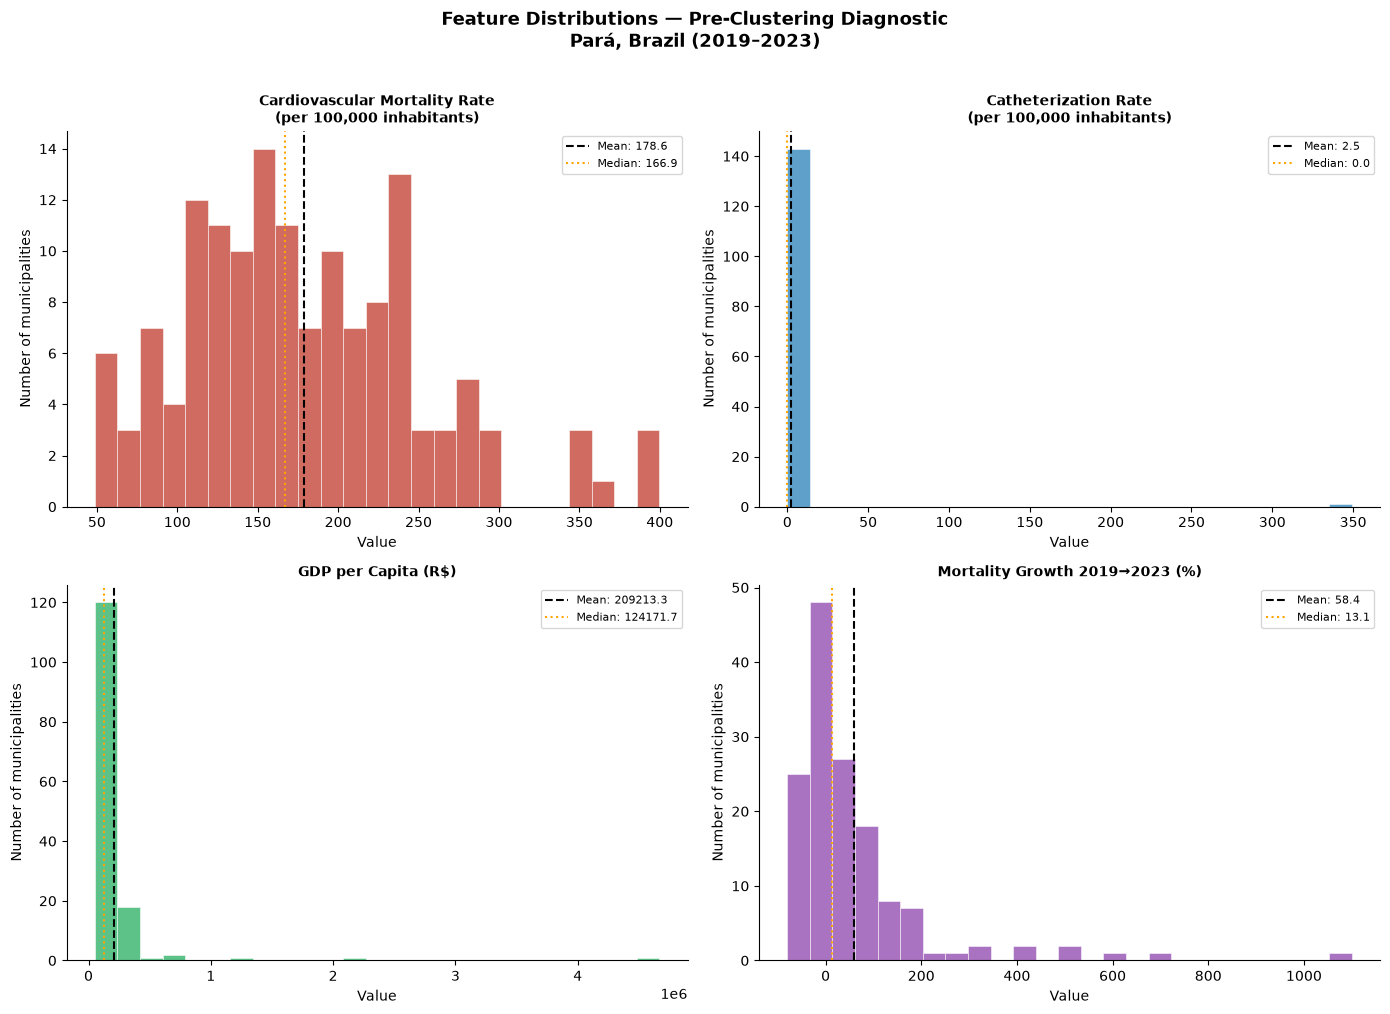

✅ Figure saved: figures/01_feature_distributions.png

=== OUTLIER REPORT (IQR method) ===

taxa_mort_100k (3 outliers):
nome_municipio  taxa_mort_100k
  CURIONOPOLIS      399.684756
       IRITUIA      395.232697
      XINGUARA      391.932359

taxa_proc_100k (2 outliers):
nome_municipio  taxa_proc_100k
         BELEM       349.17221
    ANANINDEUA        11.84286

pib_per_capita (10 outliers):
   nome_municipio  pib_per_capita
CANAA DOS CARAJAS    4.666914e+06
 VITORIA DO XINGU    2.146020e+06
      PARAUAPEBAS    1.296299e+06
     JACAREACANGA    7.605833e+05
     CURIONOPOLIS    7.483776e+05
        BARCARENA    5.383209e+05
          TUCURUI    3.802750e+05
   NOVO PROGRESSO    3.640426e+05
           MARABA    3.446442e+05
        RIO MARIA    3.408504e+05

crescimento_mort (11 outliers):
     nome_municipio  crescimento_mort
  GARRAFAO DO NORTE       1100.000000
        BRASIL NOVO        700.000000
SANTA MARIA DO PARA        600.000000
   MOJUI DOS CAMPOS        500.000000
 AGUA

In [24]:
# ── SECTION 8 — Data Quality Diagnostics ───────────────────────────────────

os.makedirs('figures', exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Distributions — Pre-Clustering Diagnostic\nPará, Brazil (2019–2023)',
             fontsize=13, fontweight='bold', y=1.01)

plot_config = [
    ('taxa_mort_100k',    'Cardiovascular Mortality Rate\n(per 100,000 inhabitants)', '#C0392B'),
    ('taxa_proc_100k',    'Catheterization Rate\n(per 100,000 inhabitants)',           '#2980B9'),
    ('pib_per_capita',    'GDP per Capita (R$)',                                       '#27AE60'),
    ('crescimento_mort',  'Mortality Growth 2019→2023 (%)',                            '#8E44AD'),
]

for ax, (col, title, color) in zip(axes.flat, plot_config):
    ax.hist(df[col].dropna(), bins=25, color=color, alpha=0.75, edgecolor='white', linewidth=0.5)
    
    mean_val   = df[col].mean()
    median_val = df[col].median()
    
    ax.axvline(mean_val,   color='black',  linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    ax.axvline(median_val, color='orange', linestyle=':',  linewidth=1.5, label=f'Median: {median_val:.1f}')
    
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Value')
    ax.set_ylabel('Number of municipalities')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/01_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure saved: figures/01_feature_distributions.png")

# ── Outlier report ──────────────────────────────────────────────────────────
print("\n=== OUTLIER REPORT (IQR method) ===")
for col in features_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)][['nome_municipio', col]]
    outliers = outliers.sort_values(col, ascending=False)
    print(f"\n{col} ({len(outliers)} outliers):")
    if len(outliers):
        print(outliers.to_string(index=False))
    else:
        print("  None")

---
## Seção 9 — Salvar Dataset Final

**Por que salvar em dois formatos:**  
- `.csv` — legível por qualquer software, GitHub-friendly
- `.parquet` — formato binário eficiente, preserva tipos de dados exatos, carrega ~10x mais rápido nos próximos notebooks

O próximo notebook (02_eda.ipynb) vai carregar direto o arquivo limpo — não vai precisar repetir toda esta limpeza.

In [25]:
# ── SECTION 9 — Save Clean Dataset ─────────────────────────────────────────

df_final = df[[
    'cod_ibge', 'nome_municipio',
    'mort_2019', 'mort_2020', 'mort_2021', 'mort_2022', 'mort_2023', 'mort_total',
    'aih_aprovadas', 'valor_total_reais',
    'populacao', 'pib_medio_mil_reais',
    'taxa_mort_100k', 'taxa_proc_100k', 'pib_per_capita', 'crescimento_mort'
]].copy()

df_final.to_csv('../data/processed/para_cardiovascular_clean.csv', index=False)
print("✅ Saved: data/processed/para_cardiovascular_clean.csv")

print(f"""
╔══════════════════════════════════════════════════════╗
║           NOTEBOOK 01 — COMPLETE                    ║
╠══════════════════════════════════════════════════════╣
║  Municipalities in dataset : {len(df_final):>3}                      ║
║  Study period              : 2019–2023               ║
║  Total CV deaths           : {int(df_final['mort_total'].sum()):>6}                 ║
║  Total catheterizations    : {int(df_final['aih_aprovadas'].sum()):>6}                 ║
║  Municipalities with cath. : {int((df_final['aih_aprovadas']>0).sum()):>3}                      ║
║  Municipalities without    : {int((df_final['aih_aprovadas']==0).sum()):>3}                      ║
║  Population baseline year  : 2021                    ║
║  GDP baseline              : 5-year average          ║
╚══════════════════════════════════════════════════════╝
Next → 02_eda.ipynb
""")

✅ Saved: data/processed/para_cardiovascular_clean.csv

╔══════════════════════════════════════════════════════╗
║           NOTEBOOK 01 — COMPLETE                    ║
╠══════════════════════════════════════════════════════╣
║  Municipalities in dataset : 144                      ║
║  Study period              : 2019–2023               ║
║  Total CV deaths           :  16677                 ║
║  Total catheterizations    :   5324                 ║
║  Municipalities with cath. :   2                      ║
║  Municipalities without    : 142                      ║
║  Population baseline year  : 2021                    ║
║  GDP baseline              : 5-year average          ║
╚══════════════════════════════════════════════════════╝
Next → 02_eda.ipynb



---
## Shapefile — Para o Notebook de Visualização

O shapefile não precisa ser limpo agora — ele é lido pelo geopandas já no formato correto. Mas vamos testá-lo aqui para garantir que está acessível.

In [ ]:
# Teste de leitura do shapefile
# O shapefile do IBGE precisa de 4 arquivos na mesma pasta: .shp, .shx, .dbf, .prj
# Se você só tem o .shx, precisa baixar o pacote completo em ibge.gov.br

try:
    mapa = gpd.read_file(PATH_SHAPEFILE)
    mapa['CD_MUN'] = mapa['CD_MUN'].astype(str).str[:6]  # padronizar para 6 dígitos
    print(f'✅ Shapefile carregado: {len(mapa)} municípios')
    print(f'Colunas: {list(mapa.columns)}')
    
    # Teste rápido de plot
    fig, ax = plt.subplots(figsize=(8, 8))
    mapa.plot(ax=ax, color='#ECF0F1', edgecolor='#95A5A6', linewidth=0.3)
    ax.set_title('Municípios do Pará — IBGE 2022', fontweight='bold')
    ax.axis('off')
    plt.savefig('figures/00_mapa_base.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Mapa base salvo')
    
except FileNotFoundError:
    print('⚠️  Shapefile não encontrado no caminho especificado.')
    print('Certifique-se de que os arquivos .shp, .shx, .dbf e .prj estão na pasta data/raw/')
except Exception as e:
    print(f'⚠️  Erro ao carregar shapefile: {e}')

---
## ✅ Checklist de Conclusão deste Notebook

Antes de seguir para o EDA, confirme:

- [ ] `para_cardiovascular_clean.csv` existe em `data/processed/`
- [ ] O número de municípios faz sentido (deve ser ~140–150)
- [ ] Apenas 2 municípios têm `aih_aprovadas > 0`
- [ ] `taxa_mort_100k` está calculada e sem NaN
- [ ] `pib_per_capita` está em reais (não em mil reais)
- [ ] Shapefile carregou sem erro

Se algum item não passou, volte à seção correspondente e ajuste o nome das colunas com base no que apareceu nos prints de inspeção.

---
*Próximo: `02_eda.ipynb` — Análise Exploratória e Visualizações*